In [22]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
from sklearn.datasets import make_blobs
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.set_printoptions(precision=2)
from lab_utils_multiclass_TF import *
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


In [23]:
#prepare and visualize a four-class dataset
#make 4-class dataset for classification
classes = 4
m = 100
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
std = 1.0
X_train, y_train = make_blobs(n_samples=m, centers = centers, cluster_std=std, random_state=30)


c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,


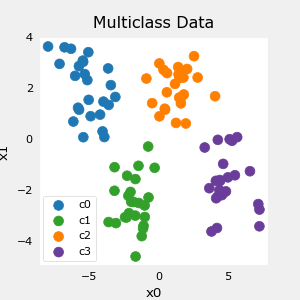

In [24]:
plt_mc(X_train, y_train, classes, centers, std=std)

In [ ]:
#each dot represents a training example, the color represent the class the example is associated with.
#the axis(x0, x1) are the inputs
#oonce trained, the model will be presented with a new example(x0,x1) and will predict the class

In [25]:
#show classes in data set
print(f'unique classes {np.unique(y_train)}')
#show how classes are represented
print(f'class representation {y_train[:10]}')
#show shapes of our dataset
print(f'shape of X_train: {X_train.shape}, \nshape of y_train: {y_train.shape}')

unique classes [0 1 2 3]
class representation [3 3 3 0 3 3 3 3 2 0]
shape of X_train: (100, 2), 
shape of y_train: (100,)


In [26]:
#model construction for 2-layer network.
#this network has 4 outputs, one for each class
#  The output layer uses a `linear` rather than `softmax` activation
#it ismore numerically stable if linear outputs are passed to the loss function during training. 
#if the model is used to predict probabilities, the softmax can be applied at that point

tf.random.set_seed(1234)   #applied to achieve consistent results
model = Sequential([
    Dense(2, activation='relu', name='L1'),
    Dense(4, activation='linear', name='L2')
])

In [27]:
#compile and train the model
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
)

model.fit(
    X_train, y_train,
    epochs=200
)

Epoch 1/200
4/4 [==============================] - 1s 4ms/step - loss: 0.9908
Epoch 2/200
4/4 [==============================] - 0s 4ms/step - loss: 0.8850
Epoch 3/200
4/4 [==============================] - 0s 14ms/step - loss: 0.8331
Epoch 4/200
4/4 [==============================] - 0s 3ms/step - loss: 0.7994
Epoch 5/200
4/4 [==============================] - 0s 3ms/step - loss: 0.7751
Epoch 6/200
4/4 [==============================] - 0s 3ms/step - loss: 0.7507
Epoch 7/200
4/4 [==============================] - 0s 4ms/step - loss: 0.7260
Epoch 8/200
4/4 [==============================] - 0s 4ms/step - loss: 0.7019
Epoch 9/200
4/4 [==============================] - 0s 3ms/step - loss: 0.6798
Epoch 10/200
4/4 [==============================] - 0s 3ms/step - loss: 0.6598
Epoch 11/200
4/4 [==============================] - 0s 2ms/step - loss: 0.6419
Epoch 12/200
4/4 [==============================] - 0s 6ms/step - loss: 0.6267
Epoch 13/200
4/4 [==============================] - 0s 3ms/s

184/184 [==============================] - 1s 3ms/step


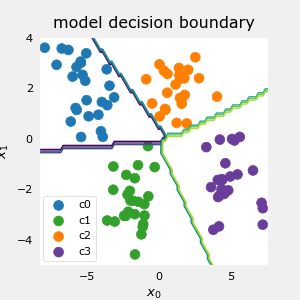

In [28]:
#see how model trained and classified the training data
plt_cat_mc(X_train, y_train, model, classes)

In [ ]:
#the above shows how the decision boundary has partitioned the input space
#how was this accomplished? Below cell explains

In [29]:
#gather the trained parameters from the first layer
l1 = model.get_layer('L1')
W1, b1 = l1.get_weights()

c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,


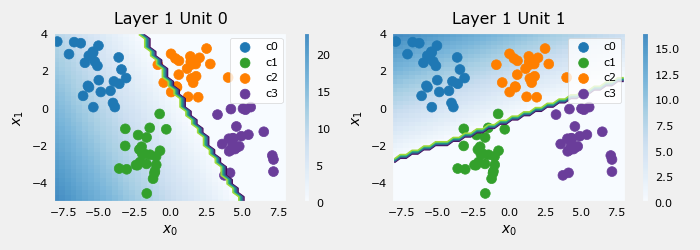

In [30]:
#plot the function of the first layer
plt_layer_relu(X_train, y_train.reshape(-1),W1, b1, classes)

In [ ]:
#explanation
''' 
Layer 1 - Unit 0
The plots shows the function of units 0 qnd 1
Unit 0 has separated classes 0 and 1 from classes 2 and 3. Classes 0 and 1 will
 output zero, while classes 2 and 3 will output one

Layer 1 - Unit 1
Has separated classes 0 and 2, and will output zero, 
while classes a and 3 will output 1
'''

c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\Doris\python1\machine_learning\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,


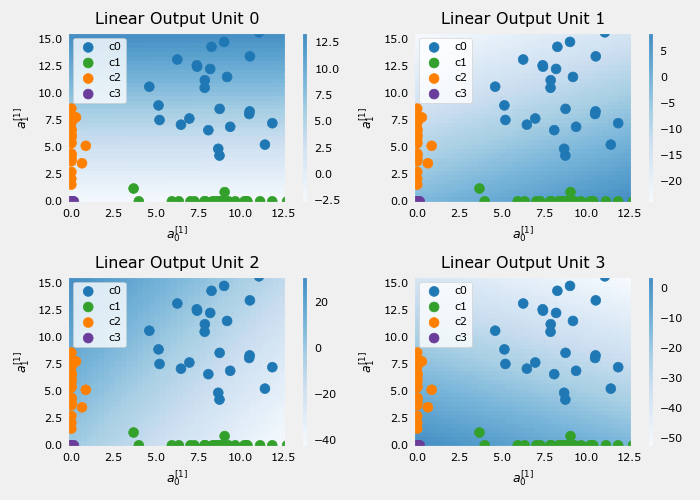

In [33]:
#gather the trained parameters from the output layer
l2 = model.get_layer('L2')
W2, b2 = l2.get_weights()
Xl2 = np.maximum(0, np.dot(X_train,W1) + b1)

plt_output_layer_linear(Xl2, y_train.reshape(-1), W2, b2, classes,
x0_rng= (-0.25, np.amax(Xl2[:,0])), x1_rng = (-0.25, np.amax(Xl2[:,1])))